# S7C-A: retarded-time bearing measurement validation

This notebook validates a supplied constant-velocity 6-D state in a homogeneous stationary medium. It contains no state estimator, filter, process noise, estimated track, GCC/SRP signal fusion, or future-measurement access. Reception timestamps drive propagation; availability timestamps are causal metadata only.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from model.dynamic_state import ConstantVelocityState
from model.measurements import BearingMeasurement
from model.retarded_bearing import predict_retarded_bearing, stack_retarded_bearing_observability
from validation.retarded_bearing_validation import run_retarded_bearing_validation, validation_stations

metrics = run_retarded_bearing_validation(Path('../results/retarded_bearing_model_summary.csv'))
metrics

{'scene_count': 1000,
 'ordinary_speed_scene_count': 950,
 'near_sonic_scene_count': 50,
 'seed': 20260901,
 'max_emission_equation_residual_s': 1.1102230246251565e-15,
 'max_analytic_numeric_emission_time_difference_s': 4.884981308350689e-15,
 'max_emission_time_jacobian_abs_mismatch': 6.915884531721872e-12,
 'max_local_direction_jacobian_abs_mismatch': 4.486511717693986e-10,
 'max_tangent_residual_jacobian_abs_mismatch': 2.725225094202255e-09,
 'max_jacobian_relative_mismatch': 3.861468973416781e-06,
 'one_station_single_bearing_rank': 2,
 'three_station_temporal_rank': 6,
 'three_station_temporal_condition_number': 9.577896723107909,
 'poor_geometry_short_window_rank': 6,
 'poor_geometry_short_window_condition_number': 4316.373666947092,
 'three_station_smallest_singular_value': 0.010160665945304471,
 'poor_geometry_smallest_singular_value': 8.72927229583684e-06}

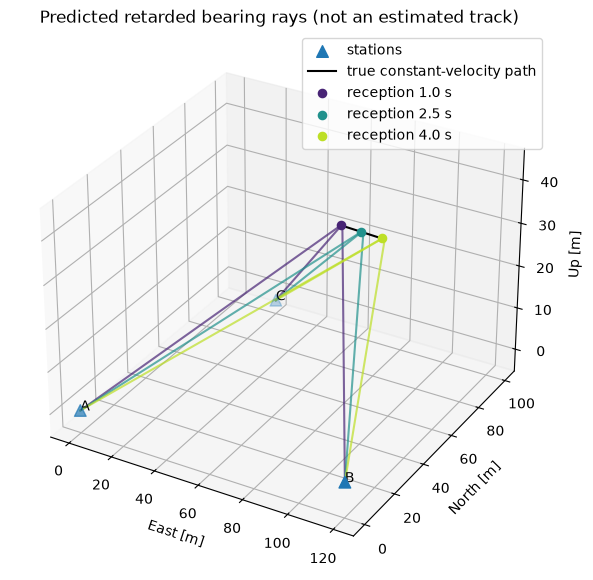

In [2]:
stations = validation_stations()
state = ConstantVelocityState([80.0, 50.0, 40.0], [8.0, -3.0, 1.0], 0.0)
reception_times = np.array([1.0, 2.5, 4.0])
predictions = [[predict_retarded_bearing(state, station, t) for station in stations] for t in reception_times]

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
station_positions = np.array([station.position_world_m for station in stations])
ax.scatter(*station_positions.T, marker='^', s=70, label='stations')
for station in stations:
    ax.text(*station.position_world_m, station.station_id)
source_times = np.linspace(min(p.emission_time_s for row in predictions for p in row), max(p.emission_time_s for row in predictions for p in row), 100)
source_path = np.array([state.position_at(t) for t in source_times])
ax.plot(*source_path.T, color='black', label='true constant-velocity path')
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(reception_times)))
for color, t, row in zip(colors, reception_times, predictions):
    for station, prediction in zip(stations, row):
        endpoint = station.position_world_m + prediction.range_m * prediction.direction_world
        segment = np.vstack([station.position_world_m, endpoint])
        ax.plot(*segment.T, color=color, alpha=0.7)
    ax.scatter(*row[0].source_position_at_emission_world_m, color=color, s=35, label=f'reception {t:.1f} s')
ax.set(xlabel='East [m]', ylabel='North [m]', zlabel='Up [m]', title='Predicted retarded bearing rays (not an estimated track)')
ax.legend(loc='best')
plt.show()

In [3]:
timing_rows = []
measurements = []
for frame, (reception, row) in enumerate(zip(reception_times, predictions)):
    for station, prediction in zip(stations, row):
        timing_rows.append((station.station_id, reception, prediction.emission_time_s, prediction.propagation_delay_s, prediction.range_m))
        measurements.append(BearingMeasurement(station.station_id, 'notebook', frame, reception, reception + 0.02, prediction.direction_local, np.diag([1e-5, 2e-5]), np.zeros(2), 'direct'))
print('station  reception_s  emission_s  delay_s  range_m')
for row in timing_rows:
    print(f'{row[0]:>7s} {row[1]:12.6f} {row[2]:11.6f} {row[3]:8.6f} {row[4]:8.3f}')
diagnostic = stack_retarded_bearing_observability(state, stations, measurements)
print()
print(f'stacked shape={diagnostic.jacobian.shape}, rank={diagnostic.rank}, condition={diagnostic.condition_number:.6g}')

station  reception_s  emission_s  delay_s  range_m
      A     1.000000    0.690533 0.309467  106.147
      B     1.000000    0.797477 0.202523   69.465
      C     1.000000    0.725301 0.274699   94.222
      A     2.500000    2.165766 0.334234  114.642
      B     2.500000    2.318895 0.181105   62.119
      C     2.500000    2.191933 0.308067  105.667
      A     4.000000    3.638941 0.361059  123.843
      B     4.000000    3.834140 0.165860   56.890
      C     4.000000    3.657880 0.342120  117.347

stacked shape=(18, 6), rank=6, condition=9.5779


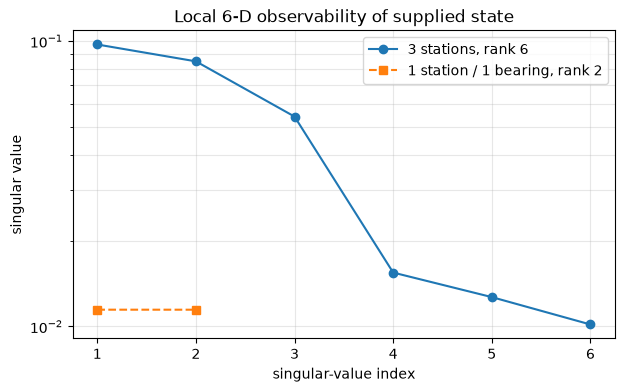

In [4]:
single_measurement = measurements[:1]
single = stack_retarded_bearing_observability(state, stations[:1], single_measurement)
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(np.arange(1, diagnostic.singular_values.size + 1), diagnostic.singular_values, 'o-', label=f'3 stations, rank {diagnostic.rank}')
ax.semilogy(np.arange(1, single.singular_values.size + 1), single.singular_values, 's--', label=f'1 station / 1 bearing, rank {single.rank}')
ax.set(xlabel='singular-value index', ylabel='singular value', title='Local 6-D observability of supplied state')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.show()

In [5]:
station = stations[0]
static_state = ConstantVelocityState([50.0, 30.0, 20.0], np.zeros(3), 0.0)
static_prediction = predict_retarded_bearing(static_state, station, 2.0)
static_expected = static_state.position_at_reference_world_m - station.position_world_m
static_expected /= np.linalg.norm(static_expected)
instant_prediction = predict_retarded_bearing(state, station, 2.0, sound_speed=1e12)
instant_expected = state.position_at(2.0) - station.position_world_m
instant_expected /= np.linalg.norm(instant_expected)
print('static direction max abs error:', np.max(np.abs(static_prediction.direction_world - static_expected)))
print('c -> infinity direction max abs error:', np.max(np.abs(instant_prediction.direction_world - instant_expected)))
print('This is a retarded-time measurement-model validation, not tracking.')

static direction max abs error: 0.0
c -> infinity direction max abs error: 5.309641615269811e-12
This is a retarded-time measurement-model validation, not tracking.
